# NB97 - Polyline CLR lane head: full training (post-fix)

**Pipeline position:** NB88-94 froze lane IoU; NB95/96 traced it to a
rasterizer unit bug (`length` not scaled by `n_strips`) and CONFIRMED the
one-line fix unfreezes IoU (NB96: IoU 0.003 -> 0.020 rising, mask-frac
0 -> 0.033). This is the first real full run on the fixed substrate.

**Config (NB96 row B = fastest geometry, stable on 2k):**
- `--lane-weights clrkd` (full CLRKDNet weights - strong geometry grad)
- `--diff-clamp none`
- `--lane-match hungarian`
- batch 32, lr0 4e-4, **epochs 120**, **patience 30**

**Two prior problems fixed here:**
1. *Frozen IoU* - rasterizer `length*n_strips` fix (NB96-confirmed).
2. *Best at epoch ~20 then decline* - `fitness` was detection-only, so
   best.pt/early-stop locked on the det peak. Now `fitness =
   det_fit + 0.5*IoU(lane)` (val.py) so best.pt follows the slower lanes,
   and EarlyStopping(patience=30) halts the run ~30 ep after the true
   multi-task peak instead of burning 200 declining epochs. best.pt is
   the deliverable.

Watch: `IoU(lane)` should climb well past 0.07; `[lane-mask]` fraction
should grow; `[lane-geom]` length mean should rise toward ~0.7; det mAP50
should hold while combined fitness keeps improving.


### Cell 1: Mount + env

In [1]:
import os, sys, subprocess
from pathlib import Path
from google.colab import drive
os.environ['PYTHONIOENCODING'] = 'utf-8'
if not Path('/content/drive').exists():
    drive.mount('/content/drive', force_remount=False)
REPO_ROOT = '/content/drive/MyDrive/EcoCAR/yolop_vehicle_lane'
if not os.path.isdir(REPO_ROOT):
    raise FileNotFoundError(f'Missing {REPO_ROOT} -- verify Drive sync.')
os.chdir(REPO_ROOT)
if REPO_ROOT not in sys.path: sys.path.insert(0, REPO_ROOT)
try:
    import scipy, mmcv  # noqa  (scipy = hungarian matching)
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'mmcv', 'scipy'])
print('[ok] env ready (scipy present for hungarian matching)')


Mounted at /content/drive
[ok] env ready (scipy present for hungarian matching)


### Cell 2: Extract the FULL BDD dataset to /content/ (70k train + 10k val)

Hardened prep: pre-flight checks the prep script + the 3 Drive source
files, then streams stdout+stderr so any error is visible (not a bare
'exit 2').


In [2]:
import sys, subprocess
from pathlib import Path

PREP_SCRIPT = Path('stage2/rmt_ppad_migration/P8_train/scripts/prepare_bdd_subset.py')
SUBSET_ROOT = Path('/content/bdd_dataset')
if not PREP_SCRIPT.exists():
    raise FileNotFoundError(f'prep script not found (sync Drive): {PREP_SCRIPT}')
required = [
    Path('/content/drive/MyDrive/EcoCAR/datasets/bdd100k_clrkd_curve.tar'),
    Path('/content/drive/MyDrive/EcoCAR/downloads/rmt_ppad_weights/BDD_detection_labels.zip'),
    Path('/content/drive/MyDrive/EcoCAR/datasets/lane_targets_clr_v1_polyline.tar.gz'),
]
missing = [str(p) for p in required if not p.exists()]
if missing:
    raise FileNotFoundError('Required Drive input(s) missing:\n  ' + '\n  '.join(missing))

if (SUBSET_ROOT / '.prep_done').exists():
    print(f'[ok] dataset already prepared at {SUBSET_ROOT}; skipping')
else:
    cmd = [sys.executable, '-u', str(PREP_SCRIPT), '--out-root', str(SUBSET_ROOT),
           '--n-train', '70000', '--n-val', '10000', '--seed', '88']
    print('  cmd:', ' '.join(cmd), flush=True)
    proc = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
    for line in proc.stdout: print(line, end='', flush=True)
    if proc.wait() != 0:
        raise RuntimeError('prep failed; see streamed output above')
    (SUBSET_ROOT / '.prep_done').write_text('ok')

for label, d in (('images/train', SUBSET_ROOT/'images/train2017'), ('images/val', SUBSET_ROOT/'images/val2017'),
                 ('lane_tgt/train', SUBSET_ROOT/'lane_targets/train2017'), ('lane_tgt/val', SUBSET_ROOT/'lane_targets/val2017')):
    n = sum(1 for _ in d.iterdir()) if d.exists() else 0
    print(f'  {label:16s} {n}')


  cmd: /usr/bin/python3 -u stage2/rmt_ppad_migration/P8_train/scripts/prepare_bdd_subset.py --out-root /content/bdd_dataset --n-train 70000 --n-val 10000 --seed 88
  curve_tar   -> /content/drive/MyDrive/EcoCAR/datasets/bdd100k_clrkd_curve.tar
  labels_zip  -> /content/drive/MyDrive/EcoCAR/downloads/rmt_ppad_weights/BDD_detection_labels.zip
  lane_tar    -> /content/drive/MyDrive/EcoCAR/datasets/lane_targets_clr_v1_polyline.tar.gz
[prep] step 1: extract curve tarball
  extracting bdd100k_clrkd_curve.tar -> /content/bdd_curve_scratch
/content/drive/MyDrive/EcoCAR/yolop_vehicle_lane/stage2/rmt_ppad_migration/P8_train/scripts/prepare_bdd_subset.py:72: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tf.extractall(dest)
  done in 103.4s
  curve images: train=/content/bdd_curve_scratch/images/train (70000 jpgs), val=/content/bdd_curve_scratch/images/val (10000 jpgs)


### Cell 3: VERIFY the synchronized flip BEFORE training (eyeball check)

Draws the lane targets on a real image, then flips BOTH the image and the
targets (using the exact same math as the patched `RandomFlip`) and
redraws. **Run this and look:** the green lane lines must hug the road
markings in BOTH panels. A lane on the left of the original must land on
the right of the flipped image, still on its road marking. If the flipped
lines are off the road, the flip is wrong - set `FLIPLR='0.0'` in the
launch cell and report back BEFORE spending GPU hours.


using /content/bdd_dataset


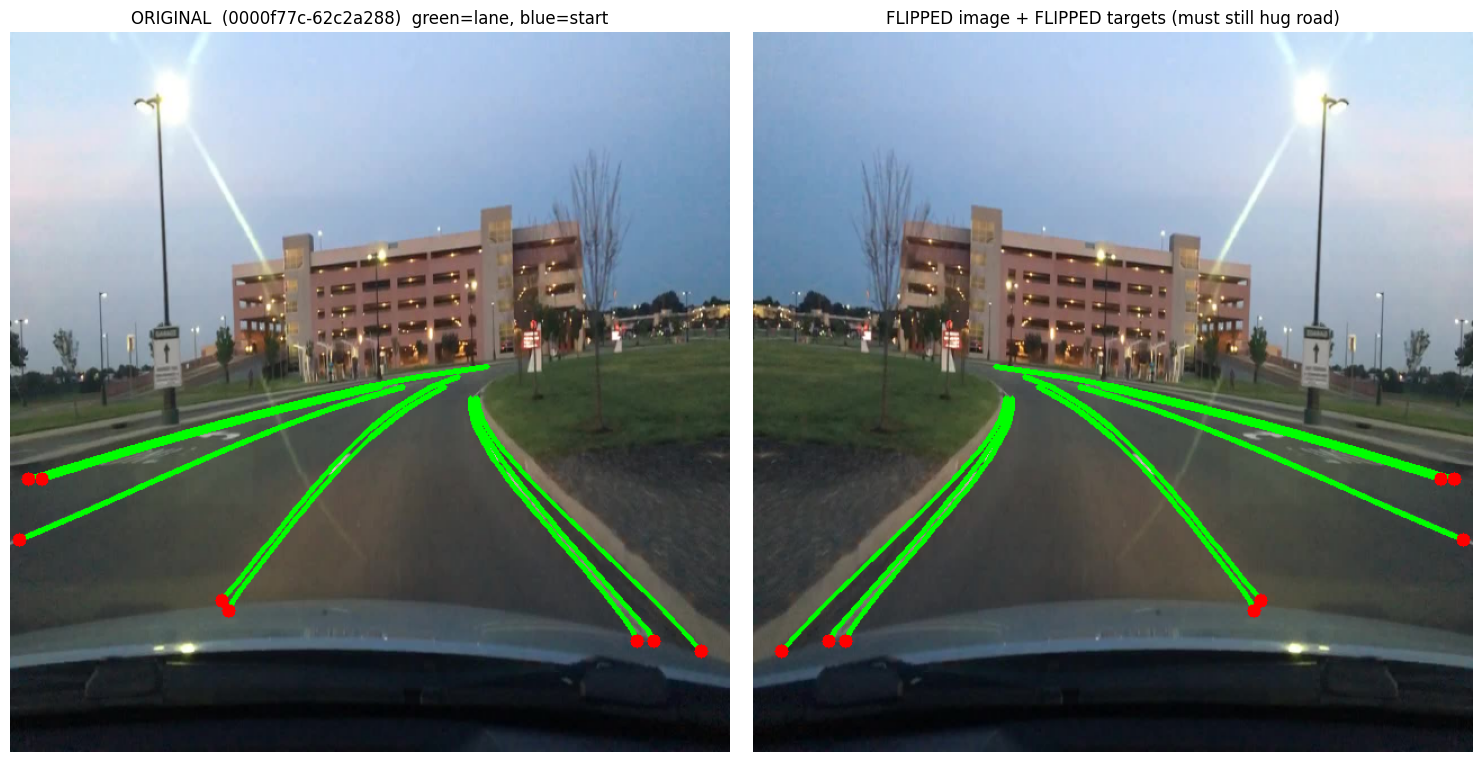

saved /content/flip_verification.png
VERDICT: lanes must hug the road in BOTH panels. If the right panel is off -> set FLIPLR=0.0 and report.


In [3]:
import numpy as np, cv2, torch
from pathlib import Path
import matplotlib.pyplot as plt

# Use whichever subset is prepared on /content/.
ROOT = None
for cand in ('/content/bdd_dataset', '/content/bdd_subset_2k', '/content/bdd_subset_10k', '/content/bdd_overfit32'):
    if (Path(cand)/'images/train2017').exists() and (Path(cand)/'lane_targets/train2017').exists():
        ROOT = Path(cand); break
if ROOT is None:
    raise FileNotFoundError('No prepared subset found - run the prep cell first.')
img_dir, tgt_dir = ROOT/'images/train2017', ROOT/'lane_targets/train2017'
print('using', ROOT)

S, NP_ = 640, 72
NS = NP_ - 1
YS = np.arange(S, -1, -S/NS)[:NP_]   # slot -> y (px). GT length is in STRIP count.

def decode(t):
    """78-D CLR target -> list of (x,y) polylines in the 640 frame."""
    out = []
    for row in t:
        if float(row[1]) < 0.5: continue
        start = max(0, min(int(round(float(row[2]) * NS)), NP_))
        length = max(0, min(int(round(float(row[5]))), NP_ - start))  # strip count
        if length < 2: continue
        xs = np.asarray(row[6 + start:6 + start + length], dtype=float)
        ys = YS[start:start + length]
        pts = [(int(round(x)), int(round(y))) for x, y in zip(xs, ys) if x > -1e4 and 0 <= x < S]
        if len(pts) >= 2: out.append(np.array(pts, dtype=np.int32))
    return out

def flip_target(t, W=S):
    """EXACT copy of the RandomFlip patch: x->W-1-x, theta->1-theta."""
    a = t.copy(); r = a[:, 1] >= 0.5
    a[r, 3] = (W - 1) - a[r, 3]            # start_x
    a[r, 4] = 1.0 - a[r, 4]               # theta
    xv = a[:, 6:]; v = r[:, None] & (xv > -1e4); xv[v] = (W - 1) - xv[v]   # x-values
    return a

def draw(im, lanes, color=(0, 255, 0)):
    o = im.copy()
    for pts in lanes:
        cv2.polylines(o, [pts.reshape(-1, 1, 2)], False, color, 3)
        cv2.circle(o, tuple(pts[0]), 6, (255, 0, 0), -1)   # start point (blue)
    return o

# pick an image with >=2 lanes so the left/right swap is obvious
chosen, tgt = None, None
for p in sorted(tgt_dir.glob('*.pt'))[:300]:
    tt = torch.load(p, weights_only=True)
    t = tt.numpy() if hasattr(tt, 'numpy') else np.asarray(tt)
    if int((t[:, 1] >= 0.5).sum()) >= 2:
        chosen, tgt = p.stem, t.astype(np.float32); break
if chosen is None:
    raise RuntimeError('no multi-lane target found in first 300 - widen the scan')

img = cv2.cvtColor(cv2.imread(str(img_dir / f'{chosen}.jpg')), cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (S, S))   # P1 squashes to 640x640, so match that

orig = draw(img, decode(tgt))
fimg = np.ascontiguousarray(np.fliplr(img))
flip = draw(fimg, decode(flip_target(tgt)))

fig, ax = plt.subplots(1, 2, figsize=(15, 7.5))
ax[0].imshow(orig); ax[0].set_title(f'ORIGINAL  ({chosen})  green=lane, blue=start'); ax[0].axis('off')
ax[1].imshow(flip); ax[1].set_title('FLIPPED image + FLIPPED targets (must still hug road)'); ax[1].axis('off')
plt.tight_layout()
png = '/content/flip_verification.png'; plt.savefig(png, dpi=80); plt.show()
print(f'saved {png}')
print('VERDICT: lanes must hug the road in BOTH panels. If the right panel is off -> set FLIPLR=0.0 and report.')


### Cell 4: Launch the full training (clrkd weights, no clamp, hungarian)

`FRESH=True` wipes any prior run dir. The training script auto-registers
the per-epoch metrics table, `[lane-geom]`/`[lane-mask]` diagnostics,
Drive sync (last.pt/best.pt/full_train.log every epoch) and the
combined-fitness early stopping. Re-run with `FRESH=False` to resume.


In [ ]:
import os, sys, subprocess, shutil
from pathlib import Path

ROW = 'clr_lane_polyline_full_v2'
# ---- CONFIG (edit here to ablate) ----
LANE_WEIGHTS = 'clrkd'      # 'clrkd' (strong geometry) | 'cut5x' (safe)
DIFF_CLAMP   = '100'        # RESTORED from 'none'. The first NB97 run with
                            # clrkd+none produced 353 ll_seg spikes up to
                            # 27,700 (a prior predicting start_x~80 normalized
                            # -> x639 px -> smooth_l1 ~25000 x weight). The
                            # spikes destabilized the lane geometry and capped
                            # IoU at ~0.085. clamp=100 bounds each prior's xytl
                            # contribution to ~50 while keeping clrkd's strong
                            # gradient. (cut5x is the even-safer fallback.)
LANE_MATCH   = 'hungarian'  # 'hungarian' | 'dynamic_k'
FLIPLR       = '0.5'        # anti-overfitting: SYNCED horizontal flip (curve
                            # targets flip too). Original RMT-PPAD trains with
                            # flip ON; we had it off = main overfit cause.
                            # Set '0.0' if lane IoU crashes (then report back).
WEIGHT_DECAY = '0.05'       # extra regularizer (Ultralytics default 0.0005)
EPOCHS, BATCH, LR0, PATIENCE = 120, 32, '4e-4', 30
FRESH = True
# --------------------------------------

YAML_MODEL = Path(REPO_ROOT)/'stage2/rmt_ppad_migration/vendor/RMT-PPAD/ultralytics/cfg/models/mt-detr/rtdetr-l_bdd_clr_lane.yaml'
YAML_DATA  = Path(REPO_ROOT)/'stage2/rmt_ppad_migration/vendor/RMT-PPAD/ultralytics/cfg/datasets/BDD_lane_only.yaml'
TRAIN = 'stage2/rmt_ppad_migration/P8_train/scripts/train_lane_only.py'
LOG_DIR = '/content/drive/MyDrive/EcoCAR/training_runs/notebook_logs'; os.makedirs(LOG_DIR, exist_ok=True)
for p in (YAML_MODEL, YAML_DATA, Path(TRAIN)):
    if not Path(p).exists(): raise FileNotFoundError(f'missing {p} (sync Drive)')

run_dir = Path('/content/runs')/ROW
if FRESH and run_dir.exists():
    print(f'[fresh] wiping {run_dir}'); shutil.rmtree(run_dir, ignore_errors=True)

from stage2.scripts.notebook_utils import run_streaming
cmd = [sys.executable, '-u', TRAIN, '--mode', 'full', '--name', ROW,
       '--project', '/content/runs', '--model-yaml', str(YAML_MODEL),
       '--data-yaml', str(YAML_DATA), '--device', '0', '--workers', '8',
       '--save-period', '10', '--batch', str(BATCH), '--epochs', str(EPOCHS),
       '--lr0', LR0, '--patience', str(PATIENCE),
       '--fliplr', FLIPLR, '--weight-decay', WEIGHT_DECAY,
       '--lane-match', LANE_MATCH, '--lane-weights', LANE_WEIGHTS, '--diff-clamp', DIFF_CLAMP]
log = os.path.join(LOG_DIR, f'NB97_{ROW}.log')
print(f'=== {ROW}: weights={LANE_WEIGHTS} clamp={DIFF_CLAMP} match={LANE_MATCH} '
      f'ep={EPOCHS} batch={BATCH} lr0={LR0} patience={PATIENCE} ===\n', flush=True)
rc = run_streaming(cmd, log_path=log, check=False)
print(f'\ntraining rc={rc}; log -> {log}')
if run_dir.exists():
    drive_tar = Path('/content/drive/MyDrive/EcoCAR/training_runs/p8_ablation')/f'{ROW}.tar.gz'
    drive_tar.parent.mkdir(parents=True, exist_ok=True)
    subprocess.check_call(['tar', '-C', '/content/runs', '-czf', str(drive_tar), ROW])
    print(f'[sync] {drive_tar} ({drive_tar.stat().st_size/1e6:.1f} MB)')


流式输出内容被截断，只能显示最后 5000 行内容。
      4/120      50.2G      16.66          0      4.846  0.0002875      107.2     0.5613     0.5244        304        640:  59%|█████▉    | 1289/2188 [12:09<08:18,  1.81it/s]
      4/120      50.2G      16.66          0      4.846  0.0002875      107.2      0.562     0.5245        278        640:  59%|█████▉    | 1289/2188 [12:10<08:18,  1.81it/s]
      4/120      50.2G      16.66          0      4.846  0.0002876      100.5      0.562     0.5247        291        640:  59%|█████▉    | 1289/2188 [12:10<08:18,  1.81it/s]
      4/120      50.2G      16.66          0      4.847  0.0002876      100.5     0.5618     0.5245        327        640:  59%|█████▉    | 1289/2188 [12:11<08:18,  1.81it/s]
      4/120      50.2G      16.66          0      4.847  0.0002876      78.71     0.5618     0.5245        395        640:  59%|█████▉    | 1289/2188 [12:12<08:18,  1.81it/s]
      4/120      50.2G      16.66          0      4.847  0.0002876      78.71     0.5618     0.524

### Cell 5: Verdict - did lane IoU climb and did best.pt track the multi-task peak?


In [ ]:
import re
from pathlib import Path
ROW = 'clr_lane_polyline_full_v2'
for base in (Path('/content/runs')/ROW/'full_train.log',
             Path('/content/drive/MyDrive/EcoCAR/training_runs/checkpoints')/ROW/'full_train.log'):
    if base.exists(): txt = base.read_text(encoding='utf-8', errors='replace'); break
else:
    print('[warn] no full_train.log; re-run cell 3'); raise SystemExit
rows = []
for l in txt.splitlines():
    m = re.match(r'\s*(\d+)\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)', l)
    if m: rows.append((int(m.group(1)), float(m.group(4)), float(m.group(6))))  # ep, mAP50, IoU(lane)
seen=set(); rows=[r for r in rows if (r[0] not in seen and not seen.add(r[0]))]
print('epoch  mAP50   IoU(lane)')
for ep, mp, iou in rows: print(f'  {ep:3d}  {mp:.4f}   {iou:.4f}')
if rows:
    ious=[r[2] for r in rows]; maps=[r[1] for r in rows]
    best_ep = rows[ious.index(max(ious))][0]
    print(f'\nIoU(lane): {min(ious):.4f} -> max {max(ious):.4f} @ep{best_ep}')
    print(f'mAP50: peak {max(maps):.4f} @ep{rows[maps.index(max(maps))][0]}, last {maps[-1]:.4f}')
    print('PASS: lane IoU climbed past 0.07' if max(ious) > 0.07 else 'CHECK: lane IoU did not exceed 0.07 - inspect [lane-geom]/[lane-mask]')
